### Phase-based encoding in pairwise neural interactions

In [2]:
import os

In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [4]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr
from frites.core import copnorm_nd
from hoi.core import get_mi
from mne.time_frequency.tfr import tfr_array_morlet, tfr_array_multitaper
from tqdm import tqdm

from src.models import simulate_kuramoto

/home/INT/brovelli.a/.local/lib/python3.10/site-packages/tqdm-4.67.1-py3.10.egg/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [14]:
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np


def make_figure(
    redundancy_data: list,  # [row_A, row_C, row_E], each a 2D array
    synergy_data: list,
    freqs: np.ndarray,  # frequency axis (shared)
    cartoon_paths: list,  # [path_A, path_C, path_E]
    panel_labels=("A", "B", "C", "D", "E", "F"),
    cmap="turbo",
    figsize=(12, 14),
    bg_color="white",
):
    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor(bg_color)

    outer = gridspec.GridSpec(
        3, 1, figure=fig, hspace=0.45, top=0.96, bottom=0.06, left=0.05, right=0.97
    )

    row_labels = [
        (panel_labels[0], panel_labels[1]),
        (panel_labels[2], panel_labels[3]),
        (panel_labels[4], panel_labels[5]),
    ]

    for row_idx in range(3):
        gs = gridspec.GridSpecFromSubplotSpec(
            1, 3, subplot_spec=outer[row_idx], width_ratios=[1, 1.6, 1.6], wspace=0.35
        )

        diag_label, heat_label = row_labels[row_idx]
        rd = redundancy_data[row_idx]
        sd = synergy_data[row_idx]
        vmax = 0.05

        # --- Cartoon panel ---
        ax_diag = fig.add_subplot(gs[0])
        ax_diag.set_facecolor(bg_color)
        for sp in ax_diag.spines.values():
            sp.set_visible(False)
        ax_diag.set_xticks([])
        ax_diag.set_yticks([])
        ax_diag.text(
            0.02,
            1.4,
            diag_label,
            transform=ax_diag.transAxes,
            color="black",
            fontsize=13,
            fontweight="bold",
            va="top",
        )
        img = mpimg.imread(cartoon_paths[row_idx])
        ax_diag.imshow(img, aspect="equal")

        # --- Redundancy heatmap ---
        ax_r = fig.add_subplot(gs[1])
        im_r = ax_r.imshow(
            rd,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            extent=[-0.5, 1, freqs[0], freqs[-1]],
            vmin=0,
            vmax=vmax,
        )
        ax_r.text(
            0.02,
            1.02,
            heat_label,
            transform=ax_r.transAxes,
            color="black",
            fontsize=13,
            fontweight="bold",
            va="bottom",
        )
        if row_idx == 0:
            ax_r.set_title("Redundancy", color="black", fontsize=10, pad=4)
        _style_heatmap_ax(
            fig, ax_r, im_r, ylabel=True, xlabel=(row_idx == 2), bg=bg_color
        )

        # --- Synergy heatmap ---
        ax_s = fig.add_subplot(gs[2])
        im_s = ax_s.imshow(
            sd,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            extent=[-0.5, 1, freqs[0], freqs[-1]],
            vmin=0,
            vmax=vmax,
        )
        if row_idx == 0:
            ax_s.set_title("Synergy", color="black", fontsize=10, pad=4)
        _style_heatmap_ax(
            fig, ax_s, im_s, ylabel=False, xlabel=(row_idx == 2), bg=bg_color
        )


def _style_heatmap_ax(fig, ax, im, ylabel, xlabel, bg):
    ax.set_facecolor(bg)
    ax.tick_params(
        colors="black",
        labelsize=8,
        which="both",
        bottom=True,
        left=True,
        labelbottom=xlabel,
        labelleft=ylabel,
    )
    for sp in ax.spines.values():
        sp.set_edgecolor("black")

    if ylabel:
        ax.set_ylabel("Frequency [Hz]", color="black", fontsize=9)

    if xlabel:
        ax.set_xlabel("Time [s]", color="black", fontsize=9)

    cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.ax.tick_params(colors="black", labelsize=8)
    cbar.outline.set_edgecolor("black")
    cbar.set_label(
        r"$I(\theta_1, \theta_2; Y)$ [bits]",
        color="black",
        fontsize=8,
        rotation=270,
        labelpad=15,
    )

In [7]:
def panzeri_treves_correction(I_obs, R, S, N):
    bias = ((R - 1) * (S - 1)) / (2 * N * np.log(2))
    return np.clip(I_obs - bias, 0, np.inf)

In [8]:
structures = ["chain", 'collider']
synergies = []
redundancies = []

In [10]:
dt = 0.001  # Integration time-step
fs = 1 / dt
f = 40  # Natural frequency
beta = 2.5  # Noise variance

for structure in structures:

    if structure == "chain":
        A = np.array([[0, 1, 0], [0, 0, 1], [0, 0, 0]]).T
        D = np.zeros_like(A)
    elif structure == "collider":
        A = np.array([[0, 0, 1], [0, 0, 1], [0, 0, 0]]).T
        D = np.zeros_like(A)
    elif structure == "visual":
        SC_data = np.load("../interareal/markov2014.npy", allow_pickle=True).item()
        # FLN matrix
        A = SC_data["FLN"][np.ix_([0, 1, 2], [0, 1, 2])]
        # Distance matrix
        D = SC_data["Distances"] * 0 * 1e-3 / 3.5
        D /= dt
        D = D[np.ix_([0, 1, 2], [0, 1, 2])]

    g = 5
    ntrials = 200
    time = np.arange(-0.5, 1, 1 / fs)  # Time array
    T = time.shape[0]

    s = 8 / (2 * np.pi * f)

    time_start = 0
    time_end = 0.4
    timestim = (
        time[(time > time_start) & (time < time_end)] - (time_end - time_start) / 2
    )
    ind = np.where((time > time_start) & (time < time_end))[0]
    gaussian = np.exp(-(timestim**2) / (2 * s**2))
    coupling = np.zeros_like(time)
    coupling[ind] = gaussian

    # Coupling strength array (linearly spaced from 1 to 100)
    CS = np.linspace(1, 100, ntrials)
    seeds = np.random.randint(0, 100000, ntrials)

    data = []
    for trial in tqdm(range(ntrials)):
        data += [
            simulate_kuramoto(
                g * A,
                D,
                coupling * CS[trial],
                f,
                fs,
                beta,
                T,
                seed=seeds[trial],
                decim=1,
            )
        ]

    h = scipy.signal.hilbert(np.stack(data).real, axis=2)

    freqs = np.linspace(20, 60, 50)
    W = tfr_array_morlet(
        data,
        fs / 1,
        freqs,
        n_cycles=freqs / 2,
        decim=1,
        output="complex",
        verbose=None,
    )


    Sxy = (W[:, 0] * np.conj(W[:, 2])).mean(0)
    Sxx = (W[:, 0] * np.conj(W[:, 0])).mean(0)
    Syy = (W[:, 2] * np.conj(W[:, 2])).mean(0)

    coh = np.abs(Sxy) ** 2 / (Sxx * Syy)

    e1 = W[:, 0] * np.conj(W[:, 1])
    e2 = W[:, 1] * np.conj(W[:, 2])
    e3 = W[:, 0] * np.conj(W[:, 2])

    # dphi1, dphi2, dphi3 = np.angle(e1), np.angle(e2), np.angle(e3)

    # dphi1 = np.abs((dphi1 + np.pi) % (2 * np.pi) - np.pi)
    # dphi2 = np.abs((dphi2 + np.pi) % (2 * np.pi) - np.pi)
    # dphi3 = np.abs((dphi3 + np.pi) % (2 * np.pi) - np.pi)

    # dphi = jnp.stack(
    #    (dphi1, dphi2, dphi3)
    # )  # jnp.stack((e1.real, e1.imag, e2.real, e2.imag, e3.real, e3.imag))

    labels = np.tile(
        np.expand_dims(np.linspace(0, 100, ntrials), (1, 2)), (e1.shape[1], e2.shape[2])
    )

    mi_fcn = get_mi("gc")

    mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2, None, None))
    mi_fcn_time_frequency = jax.vmap(mi_fcn_time, in_axes=(2, 2, None, None))

    # MI_PHI = mi_fcn_time_frequency(dphi, labels[None], False, True)

    if structure == "chain":
        # dphi1 = np.angle(e1)
        # dphi2 = np.angle(e2)

        # dphi1 = np.abs((dphi1 + np.pi) % (2 * np.pi) - np.pi)
        # dphi2 = np.abs((dphi2 + np.pi) % (2 * np.pi) - np.pi)

        z1 = e1
        z2 = e2

        dphi1 = jnp.stack((z1.real / np.abs(z1), z1.imag / np.abs(z1)))

        dphi2 = jnp.stack((z2.real / np.abs(z2), z2.imag / np.abs(z2)))

        dphi = jnp.stack(
            (
                z1.real / np.abs(z1),
                z1.imag / np.abs(z1),
                z2.real / np.abs(z2),
                z2.imag / np.abs(z2),
            )
        )

    elif structure == "collider":
        # dphi1 = np.angle(e2)
        # dphi2 = np.angle(e3)

        # dphi1 = np.abs((dphi1 + np.pi) % (2 * np.pi) - np.pi)
        # dphi2 = np.abs((dphi2 + np.pi) % (2 * np.pi) - np.pi)

        # dphi = jnp.stack((dphi1, dphi2))

        z1 = e2
        z2 = e3

        dphi1 = jnp.stack((z1.real / np.abs(z1), z1.imag / np.abs(z1)))

        dphi2 = jnp.stack((z2.real / np.abs(z2), z2.imag / np.abs(z2)))

        dphi = jnp.stack(
            (
                z1.real / np.abs(z1),
                z1.imag / np.abs(z1),
                z2.real / np.abs(z2),
                z2.imag / np.abs(z2),
            )
        )

    else:
        # dphi1 = np.angle(e1)
        # dphi2 = np.angle(e2)
        # dphi3 = np.angle(e3)

        # dphi1 = np.abs((dphi1 + np.pi) % (2 * np.pi) - np.pi)
        # dphi2 = np.abs((dphi2 + np.pi) % (2 * np.pi) - np.pi)
        # dphi3 = np.abs((dphi3 + np.pi) % (2 * np.pi) - np.pi)

        # dphi = jnp.stack((dphi1, dphi2, dphi3))

        z1 = e1
        z2 = e2
        z3 = e3

        dphi1 = jnp.stack((z1.real / np.abs(z1), z1.imag / np.abs(z1)))

        dphi2 = jnp.stack((z2.real / np.abs(z2), z2.imag / np.abs(z2)))

        dphi3 = jnp.stack((z3.real / np.abs(z3), z3.imag / np.abs(z3)))

        dphi = jnp.stack(
            (
                z1.real / np.abs(z1),
                z1.imag / np.abs(z1),
                z2.real / np.abs(z2),
                z2.imag / np.abs(z2),
                z3.real / np.abs(z3),
                z3.imag / np.abs(z3),
            )
        )

    if structure == "visual":
        mi1_ = mi_fcn_time_frequency(dphi1, labels[None], False, False)
        mi2_ = mi_fcn_time_frequency(dphi2, labels[None], False, False)
        mi3_ = mi_fcn_time_frequency(dphi3, labels[None], False, False)
        mi123_ = mi_fcn_time_frequency(dphi, labels[None], False, False)
        red = np.minimum(np.minimum(mi1_, mi2_), mi3_)
        syn = mi123_ - np.maximum(np.maximum(mi1_, mi2_), mi3_)
    else:
        mi1_ = mi_fcn_time_frequency(dphi1, labels[None], False, True)
        mi2_ = mi_fcn_time_frequency(dphi2, labels[None], False, True)
        mi123_ = mi_fcn_time_frequency(dphi, labels[None], False, True)
        red = np.minimum(mi1_, mi2_)
        syn = mi123_ - np.maximum(mi1_, mi2_)

    redundancies.append(red)
    synergies.append(syn)

100%|██████████| 200/200 [00:38<00:00,  5.22it/s]
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.8s finished
100%|██████████| 200/200 [01:00<00:00,  3.31it/s]
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.8s finished


IndexError: list index out of range

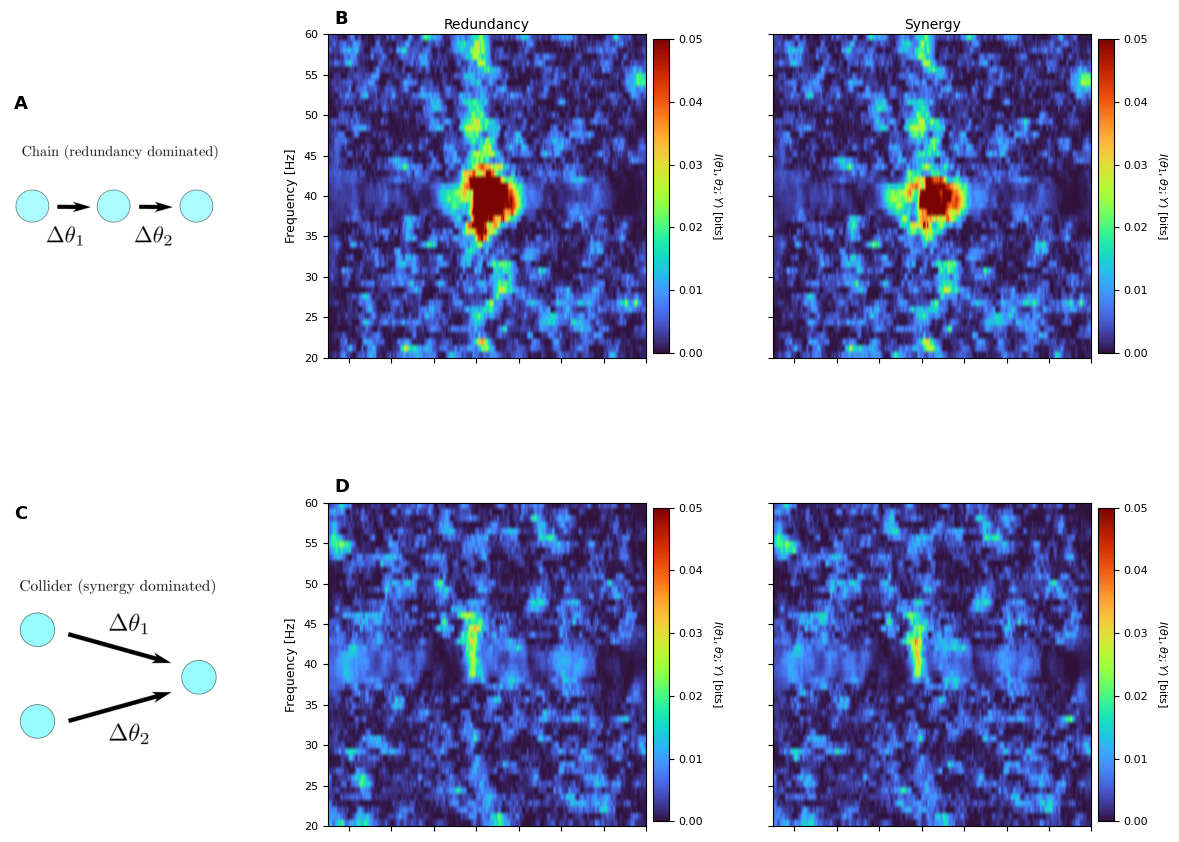

In [15]:
make_figure(
    redundancies,
    synergies,
    freqs,
    [
        "../figures/3chain_cartoon.png",
        "../figures/3collider_cartoon.png",
        "../figures/3circuit_cartoon.png",
    ],
    panel_labels=("A", "B", "C", "D", "E", "F"),
    cmap="turbo",
    figsize=(12, 14),
    bg_color="white",
)

plt.savefig("../figures/Figure2.pdf")

Figure 2: Phase-based encoding in higher-order neural interactions. Simulation of three Kuramoto
oscillators (Eq. 13) with the same parameters for all nodes (ω = 2π 40 Hz; η = 1.5), coupled via unidirectional
edges. The coupling strength among nodes was transiently modulated from 0.1 to 0.3s using a Gaussian
profile with coupling amplitude increasing from 1 to 100 across trials (n = 1000). (A) Redundant encoding
was simulated using a chain structure. Phase differences between nodes ∆θ1 and ∆θ2 were derived from
the Wavelet coefficients of the nodes’ time-series (Eq. 10; ncycles = fc/ 2; for fc ∈ [20, 60] Hz). (C) Synergistic
encoding was simulated using a collider structure. (E) Simulation of a three-nodes Kuramoto network
structured in a recurrent connectivity. Structural connectivity strengths are proportional to their anatomical
connectivity measured via retrograde tracing (FLN; Markov et al. (2013)) between three hypothetical visual
cortical areas V1, V2 and V4 circuit. The effective connectivity between nodes i and j is given by Cij · FLNij,
and the arrows representing edges are scaled accordingly. (B, D and F) Time–frequency representation of
redundant (left panel) and synergistic (right panel) information carried by phase differences ∆θ1 and ∆θ2
about the task-related variable Y, computed using the PID approach (Eqs. 6 and 7).